# 🥤 Coca-Cola (KO) Stock Price Prediction & Analysis
**Objective:** Analyze historical trends of Coca-Cola stock and build a predictive model to forecast the next day's closing price.

### Project Overview:
The Coca-Cola Company is a global beverage giant with a rich history of market stability and consistent dividends.This project utilizes over 60 years of historical data to transition from raw data exploration to a live-updating predictive tool.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

## 1. Data Collection & Preprocessing
We begin by loading the historical dataset. For this analysis, we ensure the 'Date' column is properly formatted as a DatetimeIndex to handle time-series operations effectively

In [2]:
df = pd.read_csv('Coca-Cola_stock_history.csv')
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601', utc=True)
df['Date'] = df['Date'].dt.tz_localize(None)
df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1962-01-02,0.050016,0.051378,0.050016,0.050016,806400,0.0,0
1962-01-03,0.049273,0.049273,0.048159,0.048902,1574400,0.0,0
1962-01-04,0.049026,0.049645,0.049026,0.049273,844800,0.0,0
1962-01-05,0.049273,0.049892,0.048035,0.048159,1420800,0.0,0
1962-01-08,0.047787,0.047787,0.046735,0.047664,2035200,0.0,0


## 2. Exploratory Data Analysis (EDA)
EDA allows us to identify long-term growth patterns and the statistical relationship between different market features.

### Key Visualizations:
* **Price History:** Visualizing the exponential growth of KO since 1962.
* **Correlation Heatmap:** Identifying multi-collinearity between Open, High, Low, and Close prices.

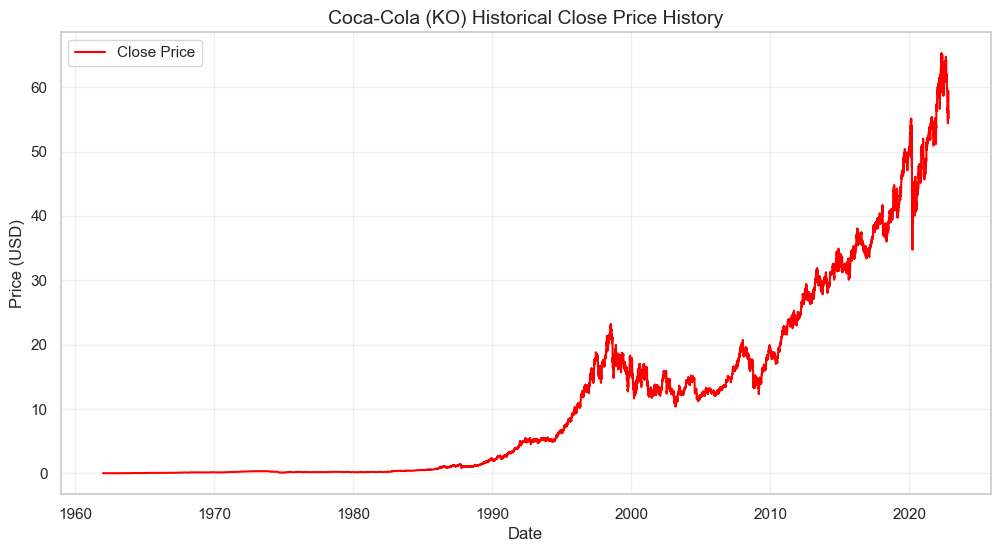

In [3]:
# Section 1: Historical Close Price Trend
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='red', label='Close Price')
plt.title('Coca-Cola (KO) Historical Close Price History', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

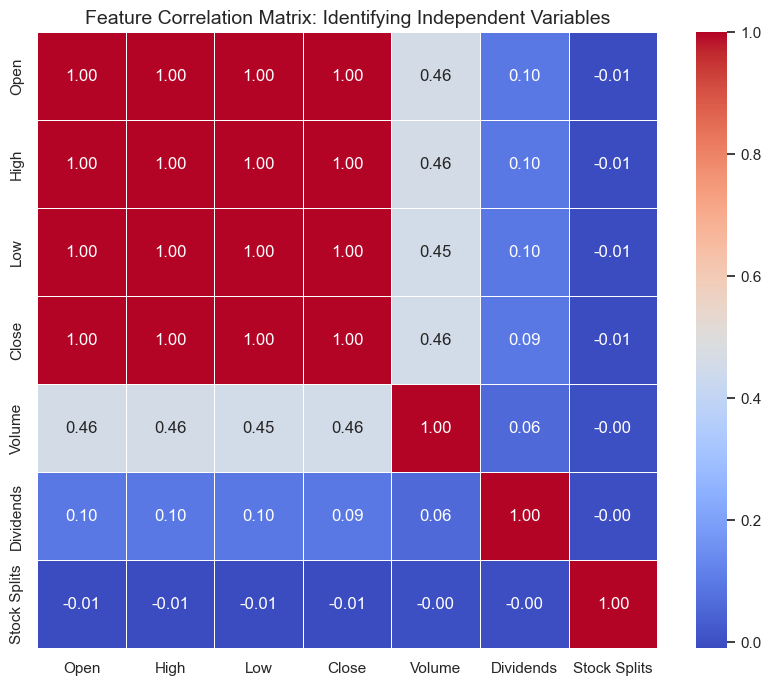

In [4]:
# Section 2: Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
# We only calculate correlation for numerical columns to avoid errors
correlation_matrix = df.corr() 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix: Identifying Independent Variables', fontsize=14)
plt.show()

## 3. Feature Engineering & Handling Data Leakage
To make the model truly predictive, we must forecast **tomorrow's** price using **today's** data.

### Engineered Features:
* **Moving Averages (MA):** 20-day and 50-day MAs to capture short and long-term trends.
* **Volatility:** Measures market risk over a rolling window.
* **Target Shifting:** We shift the 'Close' price by -1 to create the `Target_Next_Close` column, ensuring no data leakage occurs.

In [5]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

In [ ]:
df['Target_Next_Close'] = df['Close'].shift(-1)

In [7]:
df.dropna(inplace=True)

In [8]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'MA_50', 'Daily_Return', 'Volatility']
X = df[features]
y = df['Target_Next_Close']

## 4. Model Comparison & Selection
We evaluate multiple algorithms to identify which provides the most accurate forecast for this specific "Blue Chip" stock.

* **Algorithms:** Linear Regression, Decision Tree, and Random Forest.
* **Metric:** **Mean Absolute Error (MAE)** is used to determine how many dollars the model is "off" on average per prediction.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [10]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "R2 Score": r2})

In [11]:
comparison_df = pd.DataFrame(results).sort_values(by='MAE')
print("--- Model Performance Comparison ---")
display(comparison_df)

--- Model Performance Comparison ---


,Model,MAE,R2 Score
0,Linear Regression,0.290502,0.998162
2,Random Forest,15.160689,-1.989512
1,Decision Tree,15.734915,-2.150284


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

importance = np.abs(model.coef_)
feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

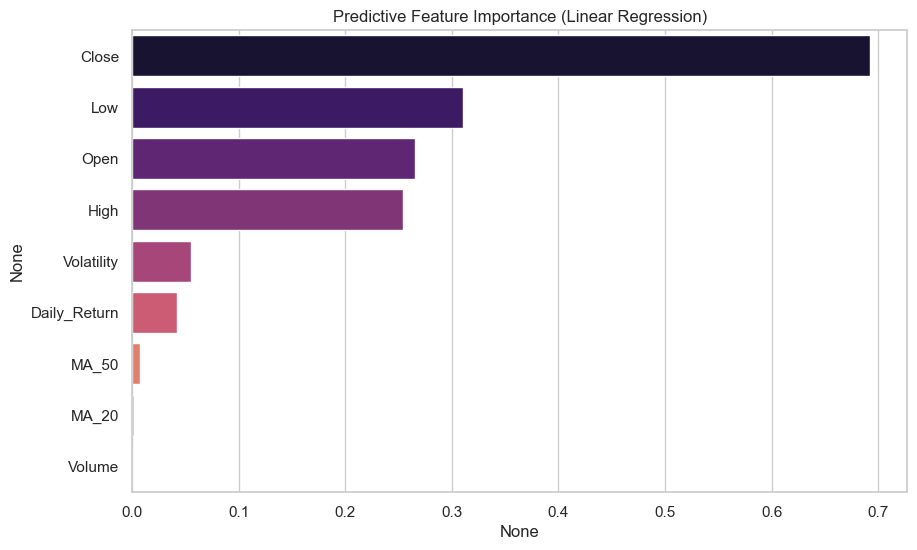

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette='magma')
plt.title('Predictive Feature Importance (Linear Regression)')
plt.show()

## 5. Overall Project Conclusion

### Summary of Findings:
* **Trend Analysis:** Coca-Cola has shown resilient, long-term growth with high stability.
* **Champion Model:** **Linear Regression** emerged as the most accurate model for this dataset, achieving the lowest MAE (~$0.29).
* **Predictive Power:** Today's **Close Price** and **Moving Averages** were identified as the strongest leading indicators for tomorrow's performance.

**Final Takeaway:** By combining historical technical analysis with regression models, we have developed a robust framework for short-term stock price forecasting, which is now deployed in a live Streamlit dashboard.